# Evaluation of a selection of models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion models trained on just one ensemble member and one time period vs 1 ensemble member three time period vs 12 ensemble members and three time periods\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare techniques: diffusion, u-net, bilinear\n\nEvaluated on all 3 time periods and all 12 ensemble members\n"
eval_vars = ["pr"]
derived_variables_config = {}
dataset_configs = {"CPM": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr"}
split = "test"
ensemble_members = [
    "01",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "15",
]
samples_per_run = 6
sample_configs = {
    "CPM": [
        {
            "label": "cCPM 1em 3TP",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_1em_cncsnpp_continuous/bham-4x_1em_pSTV",
                    "checkpoint": "epoch_120",
                    "config_hash": "8a88ee169ecf997e",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "input_xfm": "bham64_ccpm-4x_1em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "Samples": True,
            "color": "tab:orange",
            "order": 10,
        },
        {
            "label": "cCPM 12em 3TP",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 15,
        },
    ]
}
example_percentiles = {
    "CPM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    }
}
example_overrides = {}
examples_sample_idxs = [2, 5]
niterations = 30


In [ ]:
import functools
import math
import string

import IPython
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr

from mlde_analysis.utils import chained_groupby_map
from mlde_analysis.data import prep_eval_data
from mlde_analysis import plot_map
from mlde_analysis.bootstrap import resample_examples
from mlde_analysis.ccs import compute_changes, plot_changes, plot_tp_fd, plot_hist_per_tp, plot_ccs_fc_figure, ccs_fc_da
from mlde_analysis.distribution import PER_GRIDBOX_QUANTILES, normalized_mean_bias, normalized_std_bias, plot_freq_density, rms_mean_bias, rms_std_bias, compute_metrics, DIST_THRESHOLDS
from mlde_analysis.fractional_contribution import compute_fractional_contribution, frac_contrib_change, fc_bins
from mlde_analysis.wet_dry import threshold_exceeded_prop_stats, threshold_exceeded_prop_change, plot_threshold_exceedence_errors, THRESHOLDS
from mlde_analysis.display import VAR_RANGES, pretty_table
from mlde_utils import cp_model_rotated_pole, TIME_PERIODS

In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion models trained on just one ensemble member and one time period vs 1 ensemble member three time period vs 12 ensemble members and three time periods
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare techniques: diffusion, u-net, bilinear

Evaluated on all 3 time periods and all 12 ensemble members


In [ ]:
%reload_ext mlde_analysis.magics 
EVAL_DS, MODELS, CPM_DAS, PRED_DAS, VAR_DAS, MODELLABEL2SPEC = %load_eval_data
EVAL_DS

{'CPM': <xarray.Dataset> Size: 19GB
 Dimensions:                     (model: 2, sample_id: 6, ensemble_member: 12,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) float64 26kB 1.0 1.0 1.0 ... 2.0 2.0 2.0
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
   * ensemble_member             (ensemble_member) <U2 96B '01' '04' ... '15'
   * model                       (model) object 16B 'cCPM 1em 3TP' 'cCPM 12em ...
     time_period                 (time) <U8 104kB 'historic' ... 'future'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year         

In [ ]:
CCS_SEASONS = ["DJF", "JJA"]

In [ ]:
CCS_MODELS = [ model for mconfigs in MODELS.values() for model, spec in mconfigs.items() if spec.get("CCS", False) ]

CCS_PRED_DAS = { var: PRED_DAS[var].sel(model=CCS_MODELS) for var in eval_vars }

CCS_VAR_DAS = { var: VAR_DAS[var].sel(model=CCS_MODELS) for var in eval_vars }

## Figure: Climate change signal

* Per time period freq density histogram
* Mean change diff: $(\mu_{{ML}}^{{future}} - \mu_{{ML}}^{{hist}})/\mu_{{ML}}^{{hist}} - (\mu_{{CPM}}^{{future}} - \mu_{{CPM}}^{{hist}})/\mu_{{CPM}}^{{hist}}$

#### pr

##### cCPM 1em 3TP

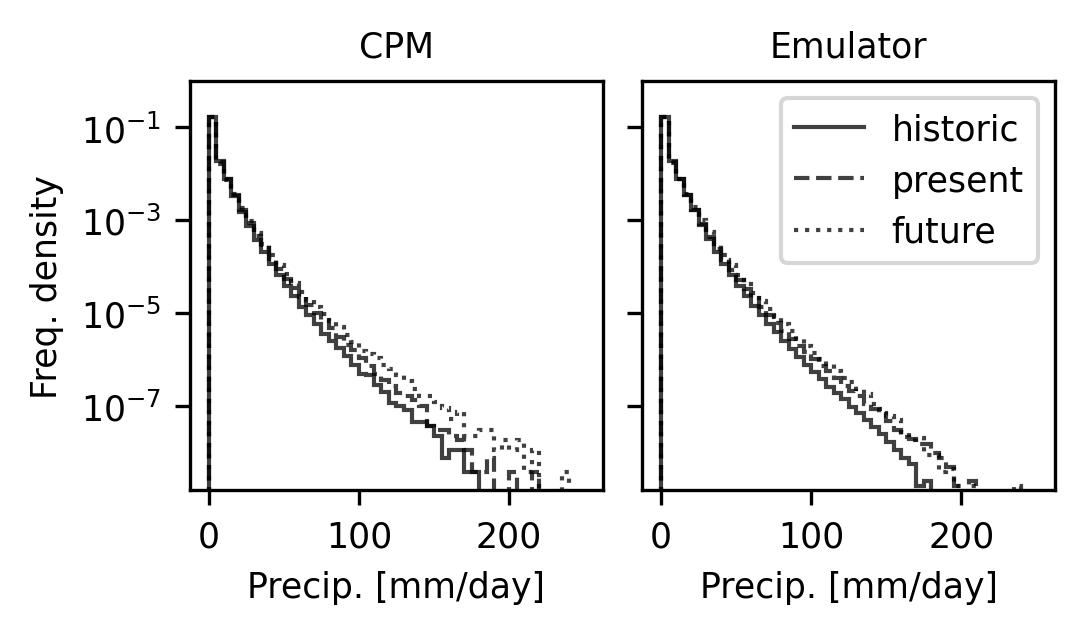

##### cCPM 12em 3TP

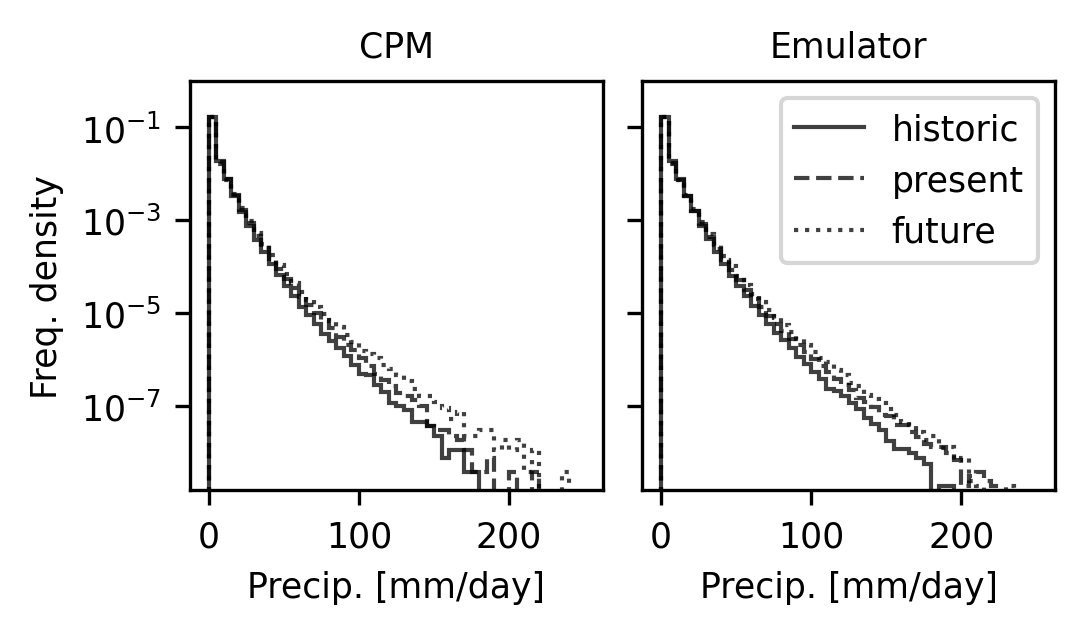

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"#### {var}", raw=True)
    for model, model_ds in CCS_VAR_DAS[var].groupby("model"):
        IPython.display.display_markdown(f"##### {model}", raw=True)

        pred_da = model_ds[f"pred_{var}"]
        cpm_da = model_ds[f"target_{var}"]
        
        fig, axd = plt.subplot_mosaic([["cpm", "model"]], figsize=(3.5, 2), constrained_layout=True, sharex=True, sharey=True)
        
        hrange=VAR_RANGES[var]
        plot_hist_per_tp(cpm_da, axd["cpm"], title="CPM",  hrange=hrange, legend=False)
        plot_hist_per_tp(pred_da, axd["model"], title="Emulator", hrange=hrange)
        axd["model"].set_ylabel(None)

        plt.show()

#### pr

##### cCPM 1em 3TP

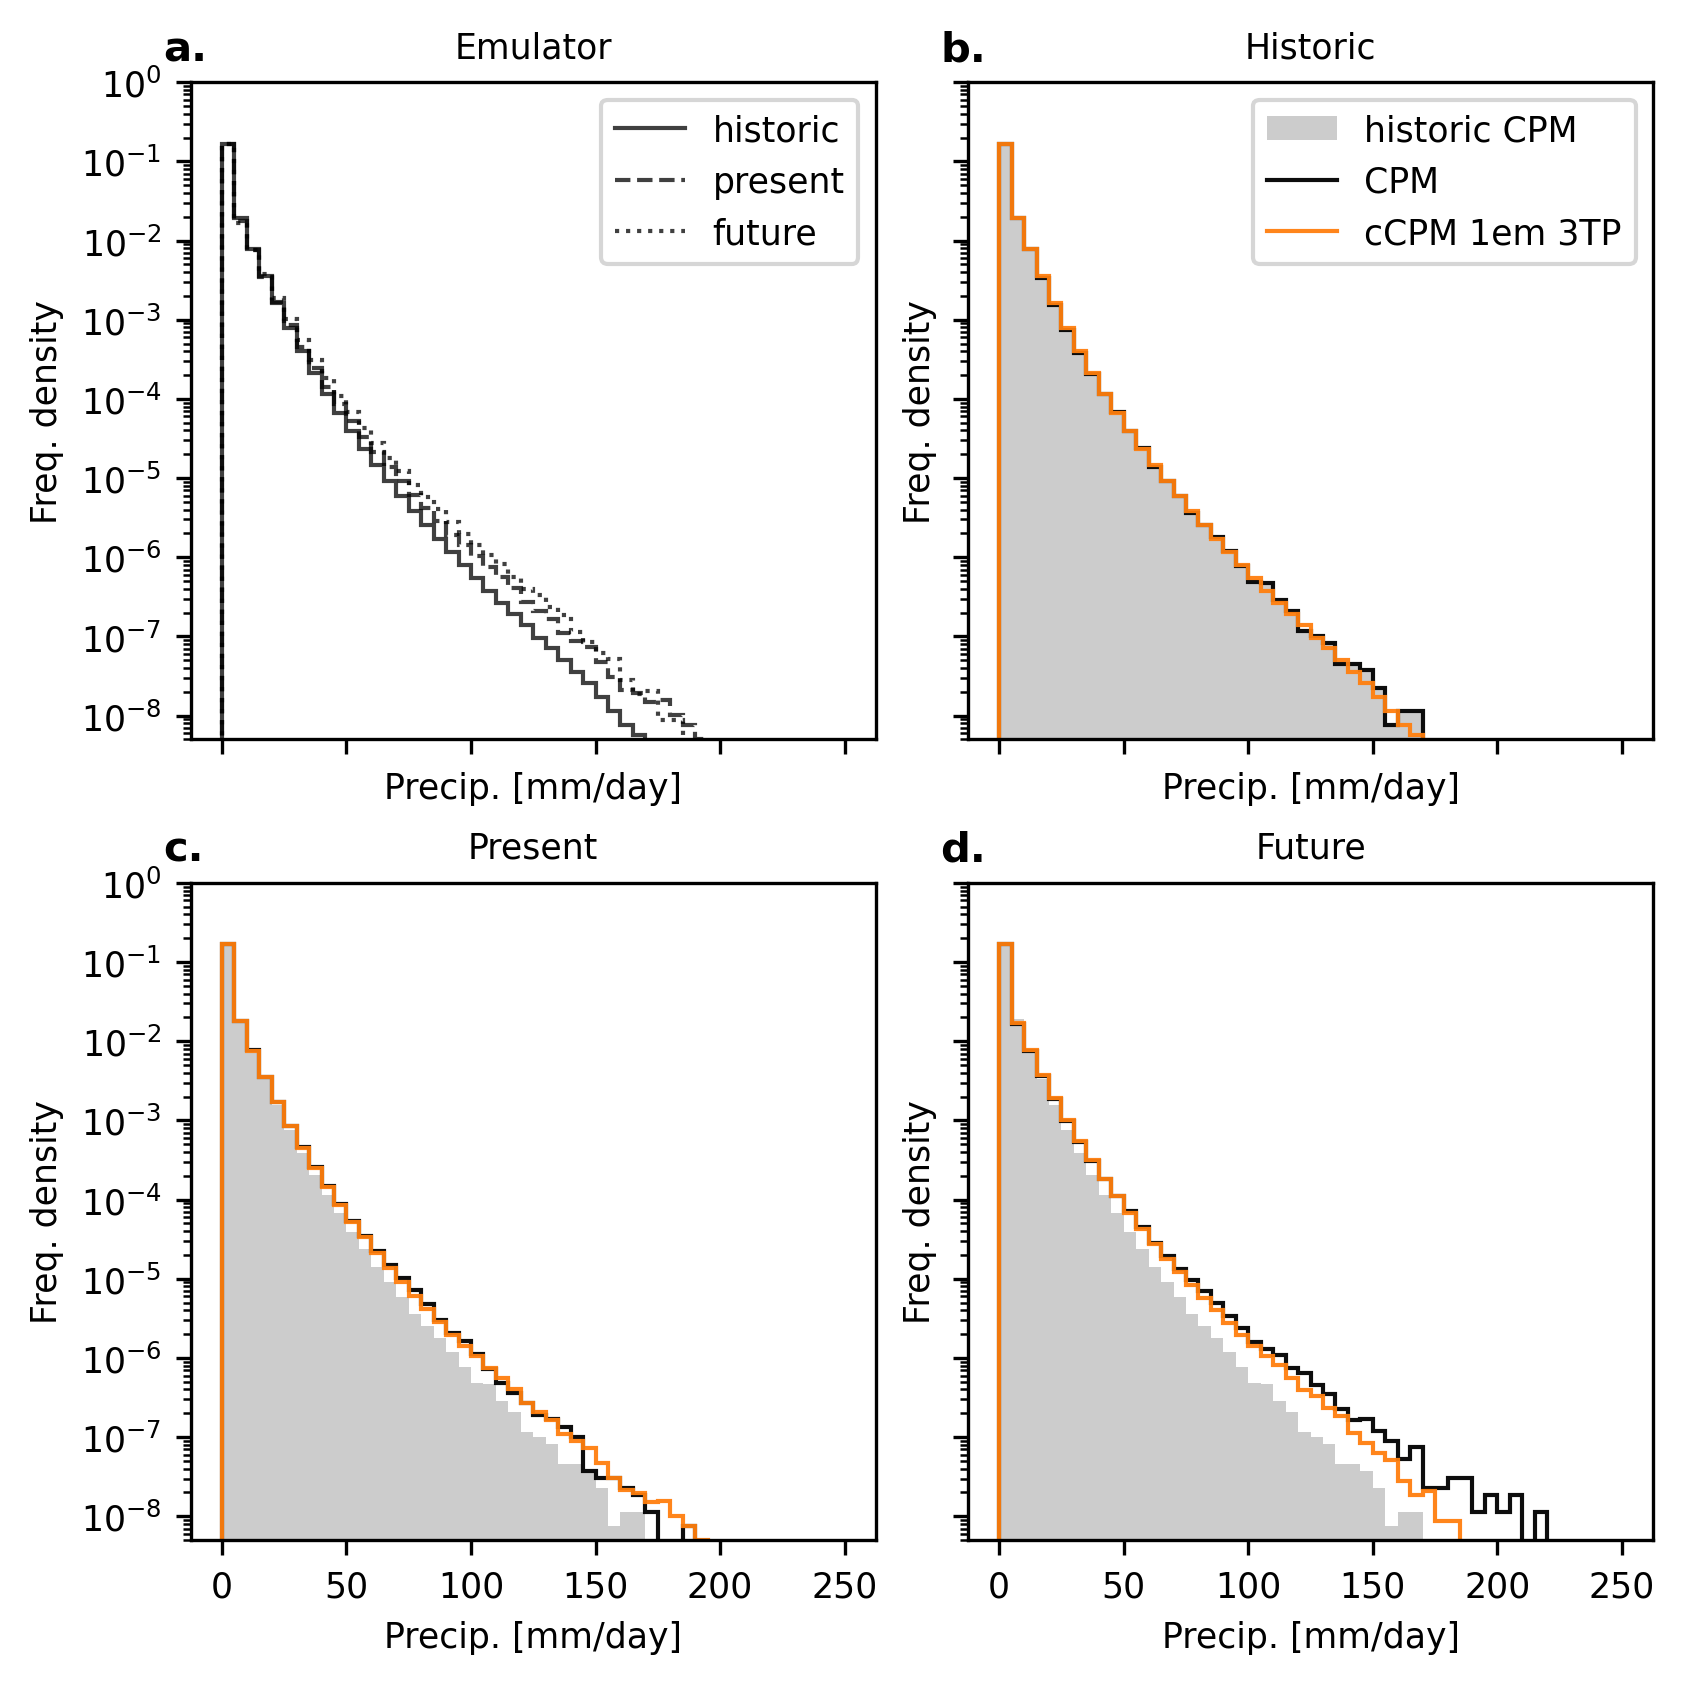

##### cCPM 12em 3TP

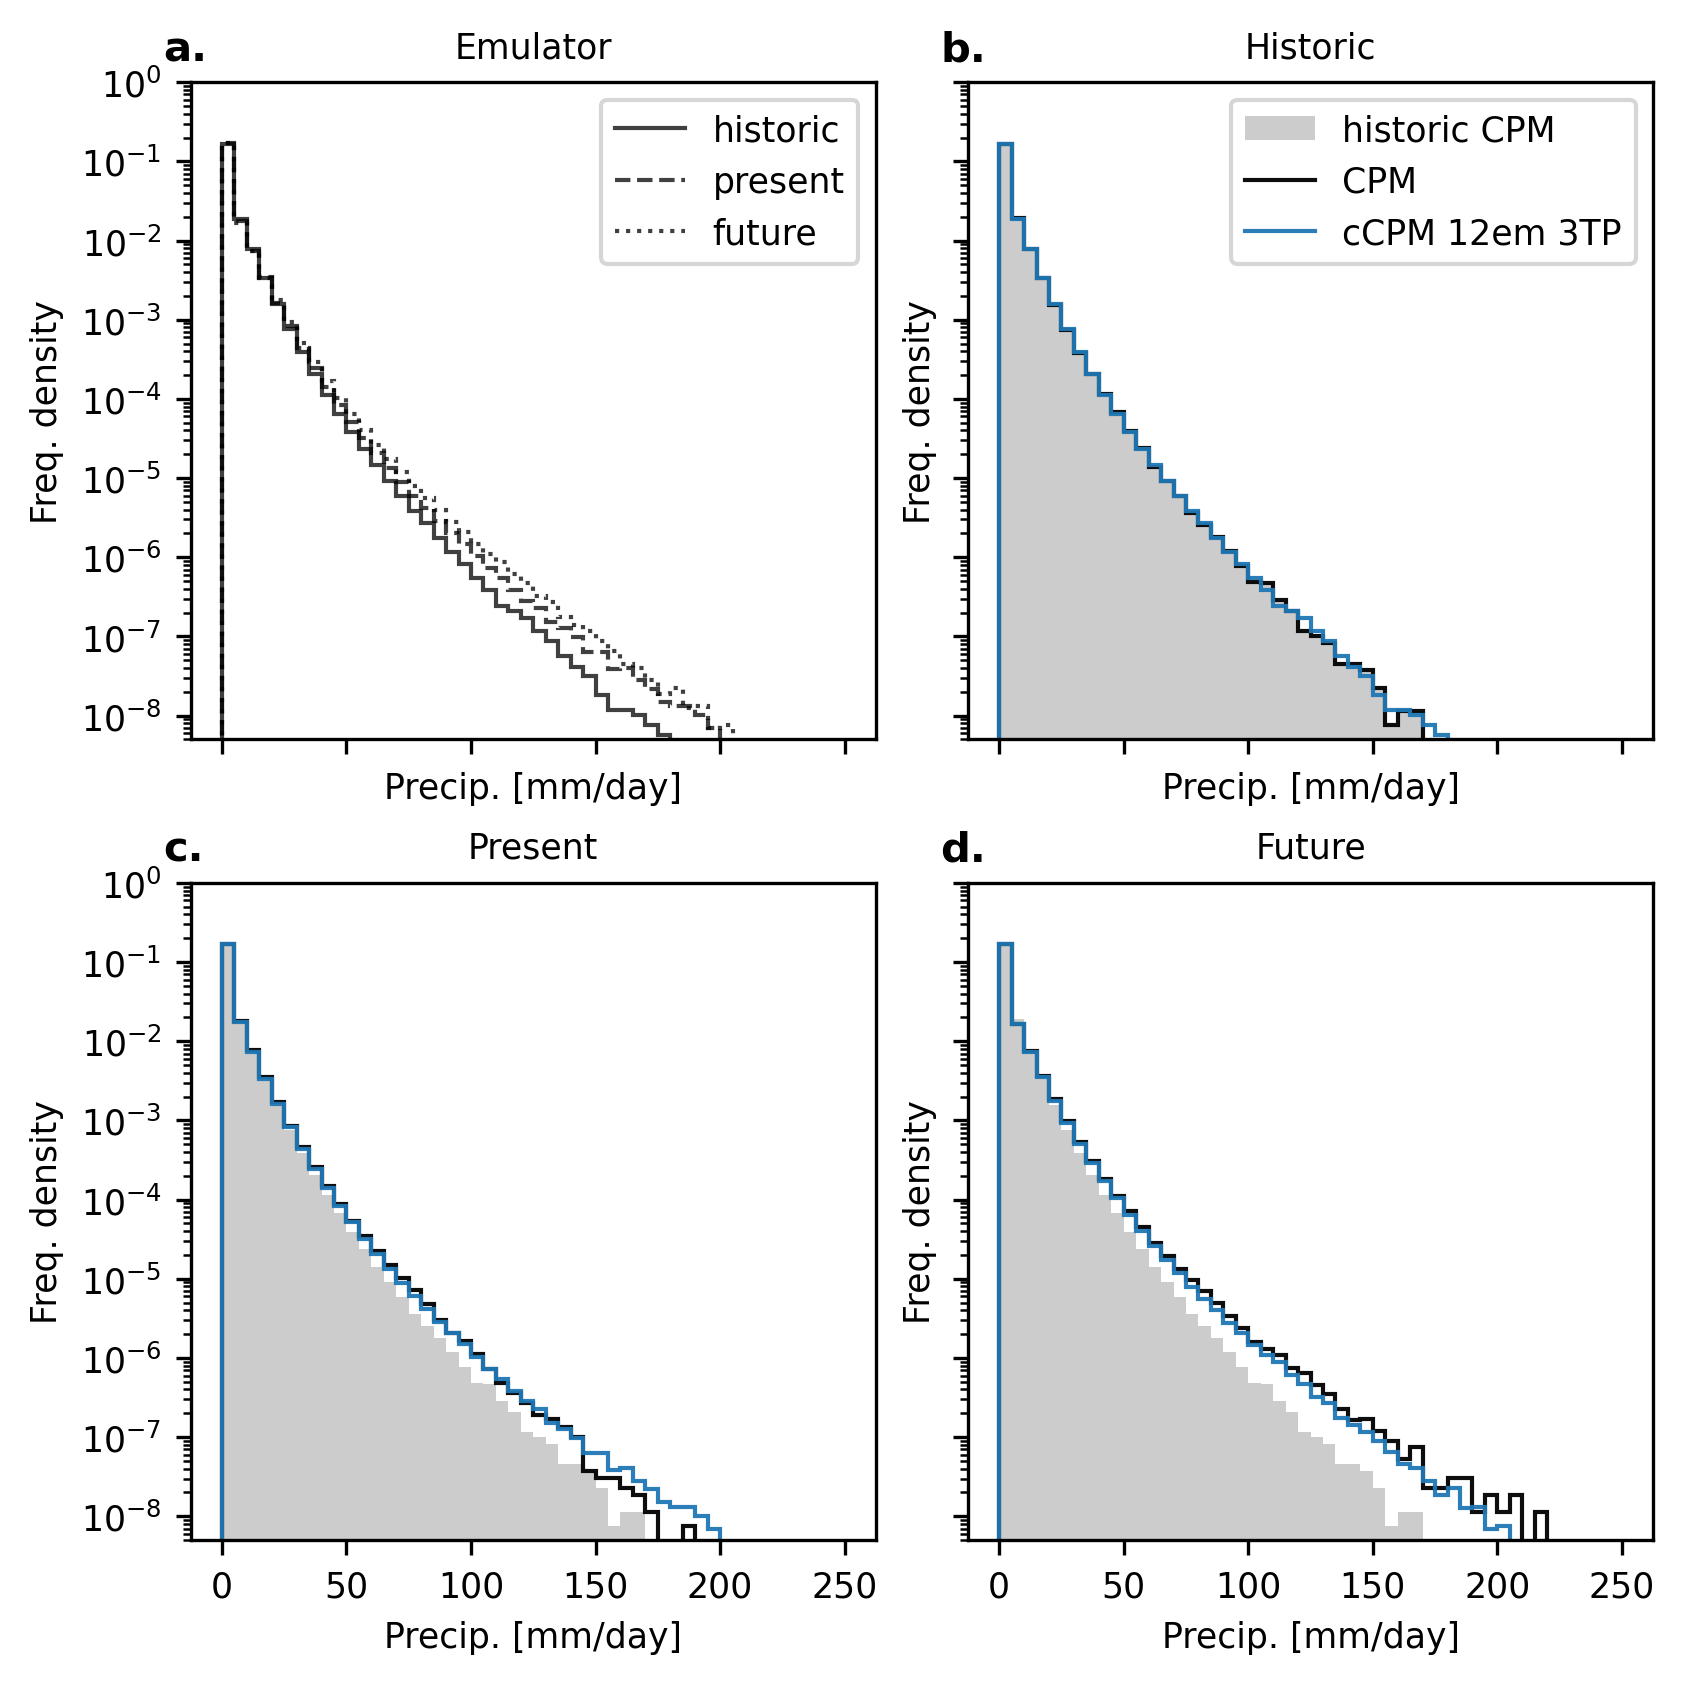

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"#### {var}", raw=True)
    for model, model_ds in CCS_VAR_DAS[var].groupby("model"):
        IPython.display.display_markdown(f"##### {model}", raw=True)

        fd_fig = plt.figure(figsize=(5.5, 5.5), layout="compressed")
        pred_da = model_ds[f"pred_{var}"]

        if var == "pr":
            hrange = (0, 250)
        else:
            hrange = None
        plot_tp_fd(pred_da, CPM_DAS[var], fd_fig, MODELLABEL2SPEC[model]["source"], model, MODELLABEL2SPEC[model], hrange=hrange)

        plt.show()

## Figure: per Time Period distribution

* Frequency Density Histogram of rainfall intensities for each time period

#### pr

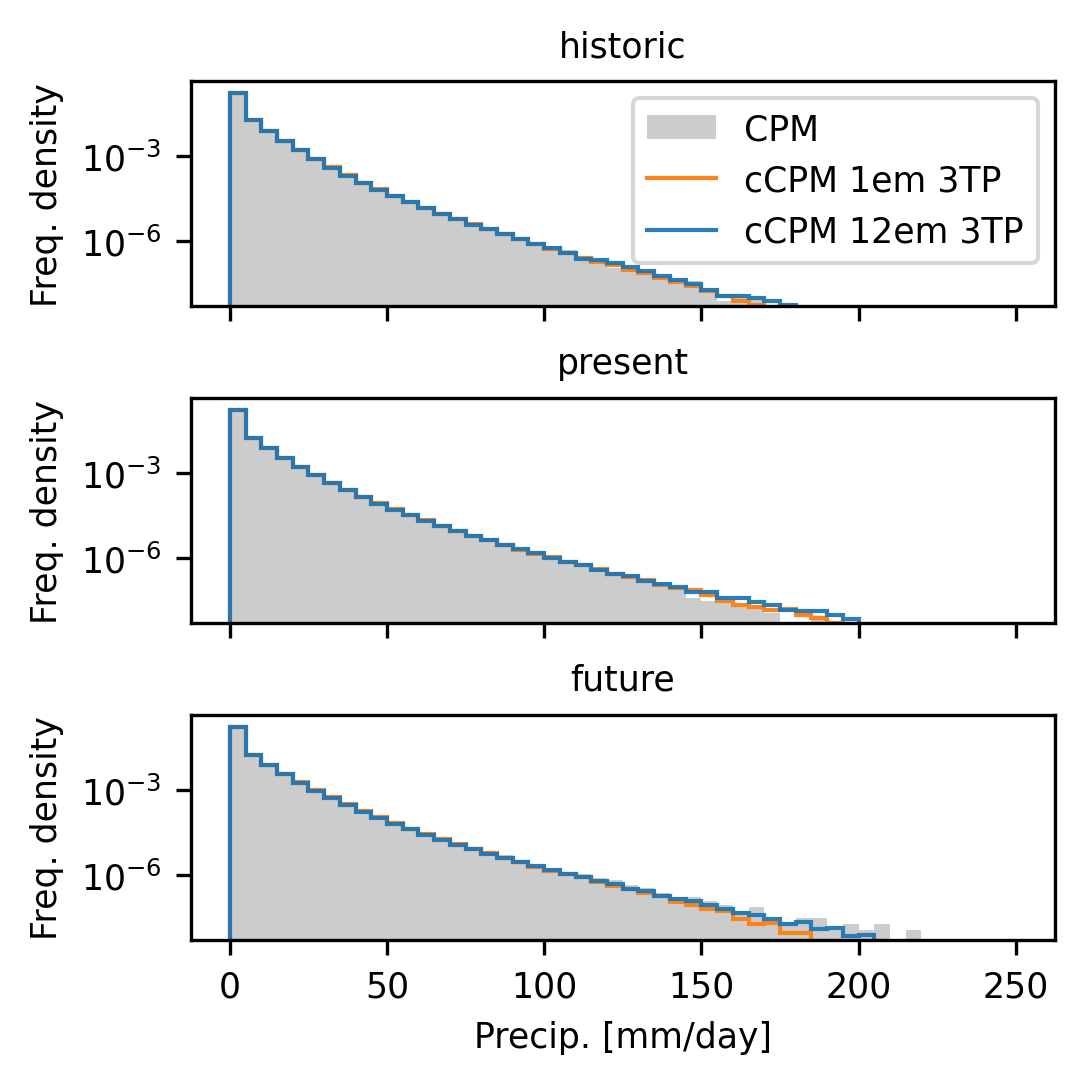

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"#### {var}", raw=True)
    
    fig = plt.figure(layout='constrained', figsize=(3.5, 3.5))
        
    # labels = [ label for mconfigs in MODELS.values() for label in mconfigs.keys() ]
    
    # meanb_axes_keys = list(map(lambda x: f"meanb {x}", labels))
    # meanb_spec = np.array(meanb_axes_keys).reshape(1,-1)
    
    # stddevb_axes_keys = list(map(lambda x: f"stddevb {x}", labels))
    # stddevb_spec = np.array(stddevb_axes_keys).reshape(1,-1)
    
    dist_spec = np.array(list(TIME_PERIODS.keys())).reshape(-1,1)
    
    spec = dist_spec
    
    axd = fig.subplot_mosaic(spec, sharex=True, sharey=True)#, gridspec_kw=dict(height_ratios=[3, 2, 2]), per_subplot_kw={ak: {"projection": cp_model_rotated_pole} for ak in meanb_axes_keys + stddevb_axes_keys})
    
    for tp_key, tp_ds in CCS_VAR_DAS[var].groupby("time_period"):
        ax = axd[tp_key]
    
        hist_data = [ dict(data=model_ds[f"pred_{var}"], label=model, color=MODELLABEL2SPEC[model]["color"]) for model, model_ds in tp_ds.groupby("model") ]
        hrange=VAR_RANGES[var]
        plot_freq_density(hist_data, ax=ax, target_da=tp_ds[f"target_{var}"], legend=(tp_key=="historic"), linewidth=1, title=tp_key, hrange=hrange)

        ax.xaxis.label.set_visible(tp_key == "future")    

    plt.show()

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    metrics_ds = CCS_VAR_DAS[var].groupby("time_period").map(lambda tp_ds: compute_metrics(tp_ds[f"pred_{var}"], tp_ds[f"target_{var}"], thresholds=DIST_THRESHOLDS[var]))
    pretty_table(metrics_ds, round=4, dim_order=["time_period", "model"])

### pr

NaN Count 
 RMS Mean Bias (mm/day) 
 RMS Std Dev Bias (mm/day) 
 RMS Q999 Bias (mm/day) 
 Relative RMS Mean Bias (%) 
 Relative RMS Std Dev Bias (%) 
 Relative RMS Q999 Bias (%) 
 J-S distance 
 Emu > 0.1 
 Emu > 0.1 - CPM > 0.1 
 Emu > 25 
 Emu > 25 - CPM > 25 
 Emu > 75 
 Emu > 75 - CPM > 75 
 Emu > 125 
 Emu > 125 - CPM > 125 
 quantile 
 
 
 time_period 
 model 
   
   
   
   
   
   
   
   
   
   
   
   
   
   
   
   
   
 
 
 
 
 future 
 cCPM 1em 3TP 
 0 
 0.09698 
 0.2042 
 3.542 
 3.02 
 3.556 
 7.405 
 0.00269 
 0.4941 
 -0.007526 
 0.01183 
 0.0002004 
 0.0001413 
 -3.165e-05 
 5.84e-06 
 -3.692e-06 
 0.999 
 
 
 cCPM 12em 3TP 
 0 
 0.09979 
 0.2382 
 3.405 
 4.196 
 4.617 
 7.185 
 0.003984 
 0.4922 
 -0.009447 
 0.01095 
 -0.0006795 
 0.0001413 
 -3.164e-05 
 6.939e-06 
 -2.593e-06 
 0.999 
 
 
 historic 
 cCPM 1em 3TP 
 0 
 0.1155 
 0.1878 
 2.762 
 3.577 
 3.302 
 6.598 
 0.003274 
 0.5596 
 0.003492 
 0.008449 
 0.0002993 
 5.997e-05 
 5.149e-07 
 1.655e-06 
 -2.104e-07 
 0.999 
 
 
 cCPM 12em 3TP 
 0 
 0.08809 
 0.1508 
 2.579 
 2.673 
 2.68 
 6.189 
 0.001882 
 0.5584 
 0.002274 
 0.008211 
 6.046e-05 
 6.15e-05 
 2.047e-06 
 2.028e-06 
 1.633e-07 
 0.999 
 
 
 present 
 cCPM 1em 3TP 
 0 
 0.1052 
 0.2273 
 3.69 
 3.713 
 4.255 
 7.993 
 0.00117 
 0.5277 
 -0.004597 
 0.009624 
 -0.0002108 
 0.0001016 
 -1.11e-05 
 4.144e-06 
 3.014e-07 
 0.999 
 
 
 cCPM 12em 3TP 
 0 
 0.1022 
 0.2271 
 3.555 
 4.14 
 4.416 
 7.572 
 0.004392 
 0.5264 
 -0.005918 
 0.009425 
 -0.0004102 
 0.0001023 
 -1.038e-05 
 4.675e-06 
 8.32e-07 
 0.999

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    
    quantiles_da = xr.concat([
        chained_groupby_map(
            CCS_VAR_DAS[var][f"pred_{var}"], 
            ["model", "time_period"], 
            lambda gda: gda.quantile(q=PER_GRIDBOX_QUANTILES, dim=["ensemble_member", "time", "sample_id"])
        ),
        chained_groupby_map(
            CCS_VAR_DAS[var][f"target_{var}"], 
            ["time_period"], 
            lambda gda: gda.quantile(q=PER_GRIDBOX_QUANTILES, dim=["ensemble_member", "time"])
        ).expand_dims(model=["CPM"])],
        dim="model",
    )
    
    quantiles_change_da = (100*(quantiles_da.sel(time_period="future") - quantiles_da.sel(time_period="historic")) / quantiles_da.sel(time_period="historic")).drop_vars("time_period").rename("Relative change in quantile [%]")
    
    pretty_table(
        quantiles_change_da.mean(["grid_latitude", "grid_longitude"]), 
        round=2, 
        caption="Domain mean of annual quantile changes",
        dim_order=["quantile", "model"],
    )

### pr

Domain mean of annual quantile changes 
 
 
   
   
 Relative change in quantile [%] 
 
 
 quantile 
 model 
   
 
 
 
 
 0.990000 
 cCPM 1em 3TP 
 12 
 
 
 cCPM 12em 3TP 
 9.7 
 
 
 CPM 
 12 
 
 
 0.999000 
 cCPM 1em 3TP 
 15 
 
 
 cCPM 12em 3TP 
 14 
 
 
 CPM 
 17

## Figure: Fractional contribution

* Fractional contribution of rainfall intensities for each time period
* Change in fractional contribution of rainfall intensities from historic to future

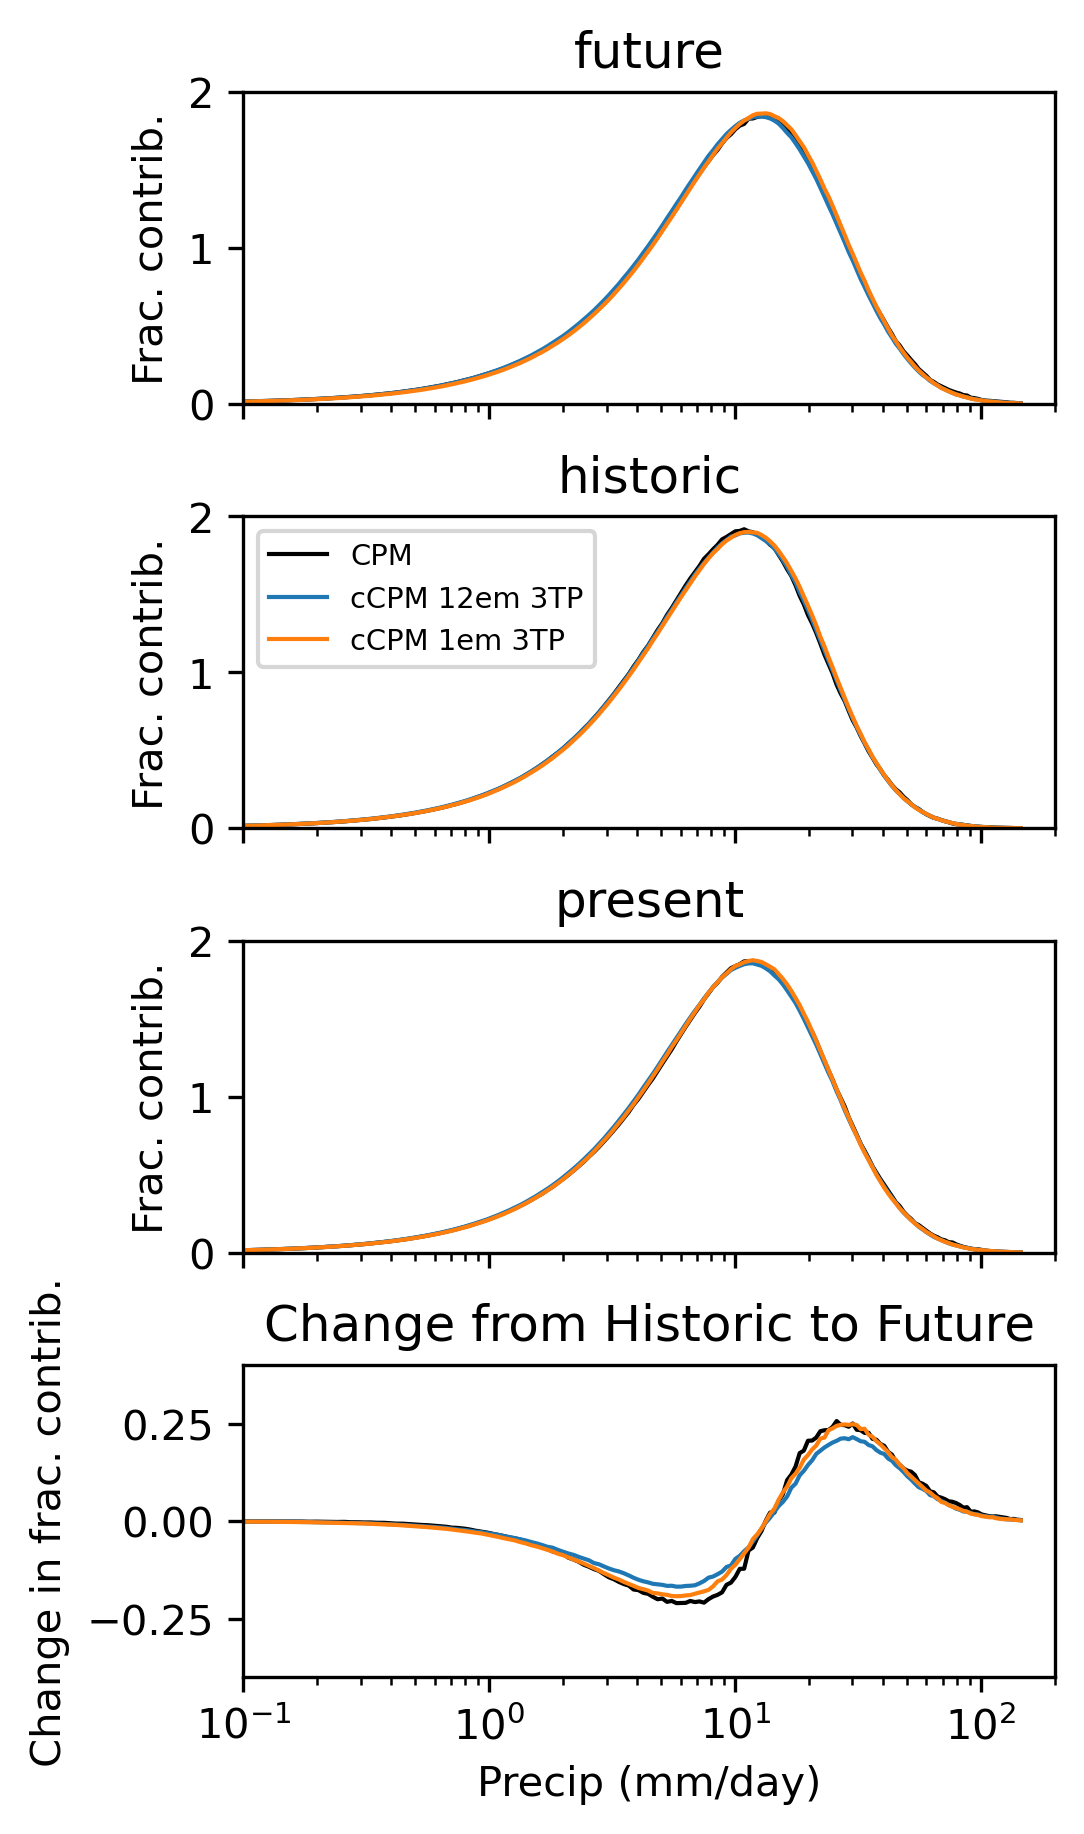

In [ ]:
for var in eval_vars:
    if var not in ["pr"]:
        continue
    
    fcdata = ccs_fc_da(CCS_VAR_DAS[var][f"pred_{var}"], CCS_VAR_DAS[var][f"target_{var}"])
    fig = plt.figure(layout='constrained', figsize=(3.5, 6))
    plot_ccs_fc_figure(fig, fcdata, palette={label: spec["color"] for label, spec in MODELLABEL2SPEC.items()})
    plt.show()

### Bootstrapped fractional contributions

In [ ]:
import gc

bs_cpm_das = { var: chained_groupby_map(CCS_VAR_DAS[var][f"target_{var}"], ["time_period", "time.season"], resample_examples, niterations=niterations) for var in eval_vars if var in ["pr"] }

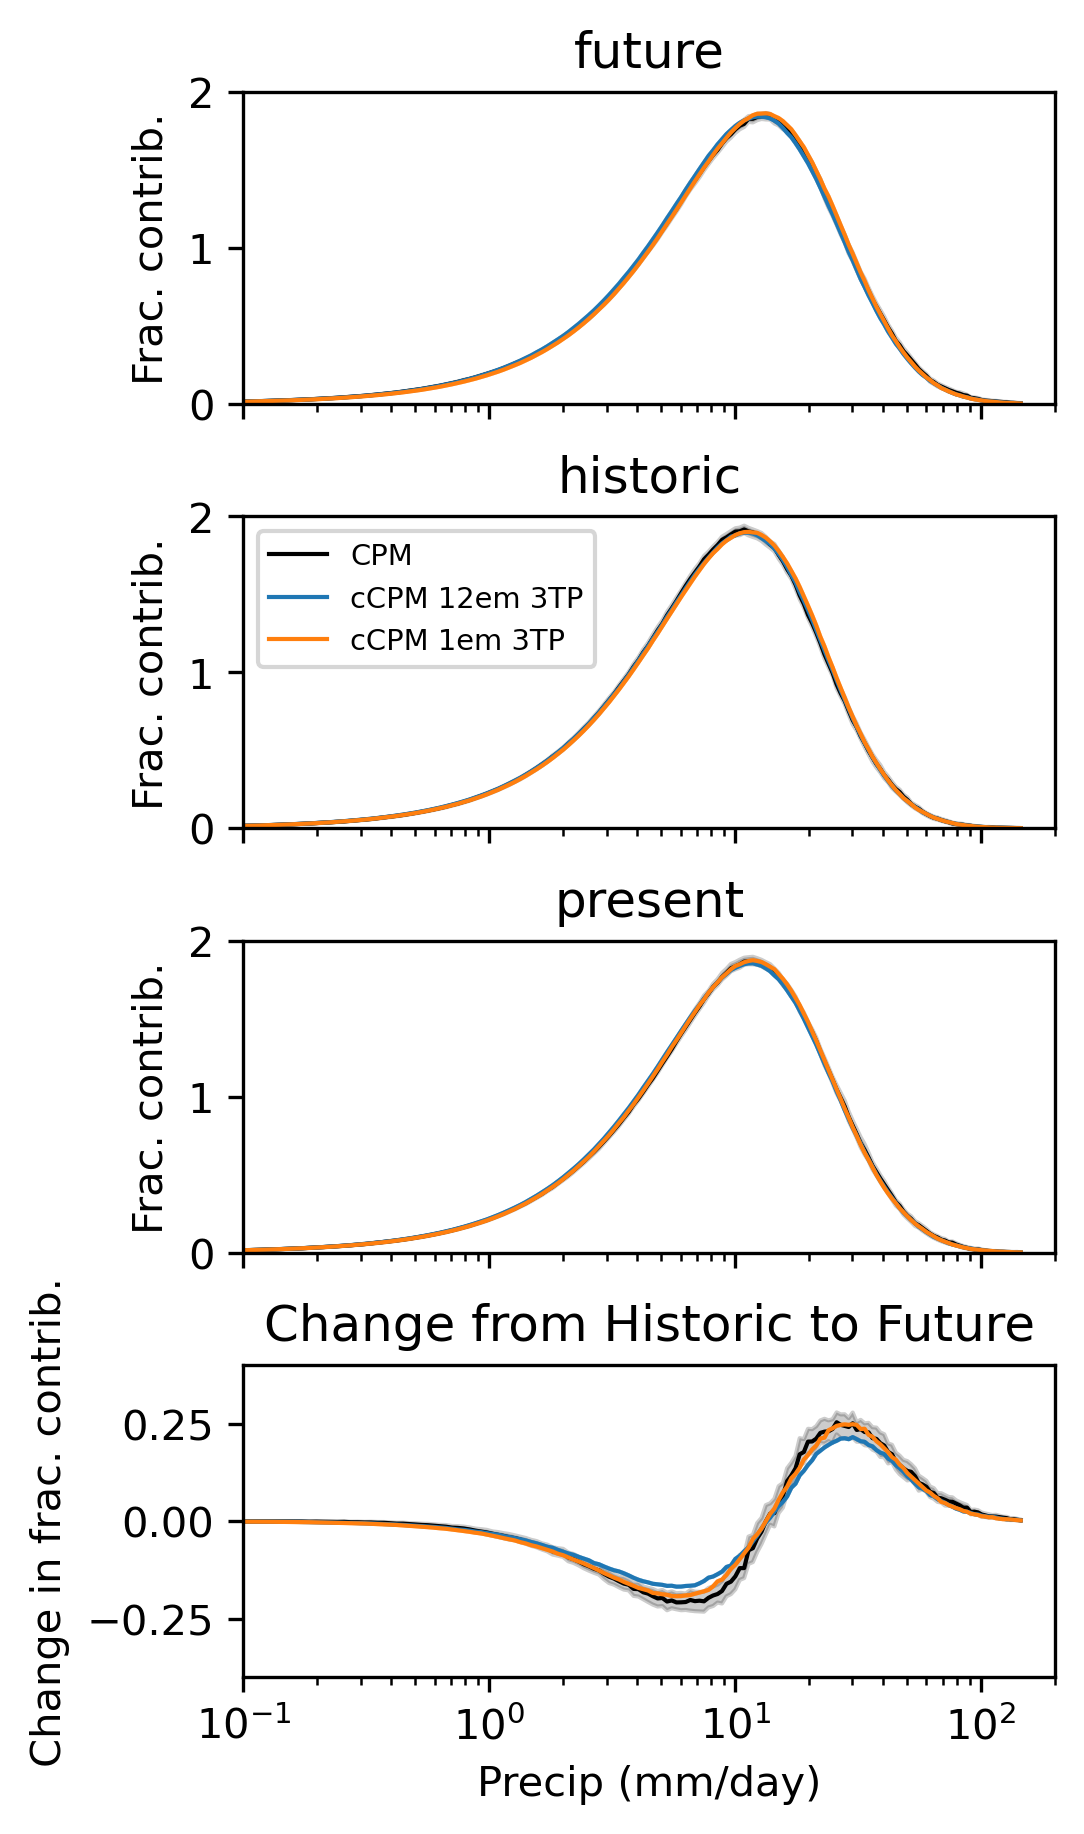

In [ ]:
for var, bs_cpm_da in bs_cpm_das.items():
    
    fcdata = ccs_fc_da(CCS_VAR_DAS[var][f"pred_{var}"], bs_cpm_da, extra_cpm_dims=["iteration"])
    
    fig = plt.figure(layout='constrained', figsize=(3.5, 6))
    plot_ccs_fc_figure(fig, fcdata, palette={label: spec["color"] for label, spec in MODELLABEL2SPEC.items()}, errorbar=("pi", 90))
    plt.show()

#### cCPM 1em 3TP

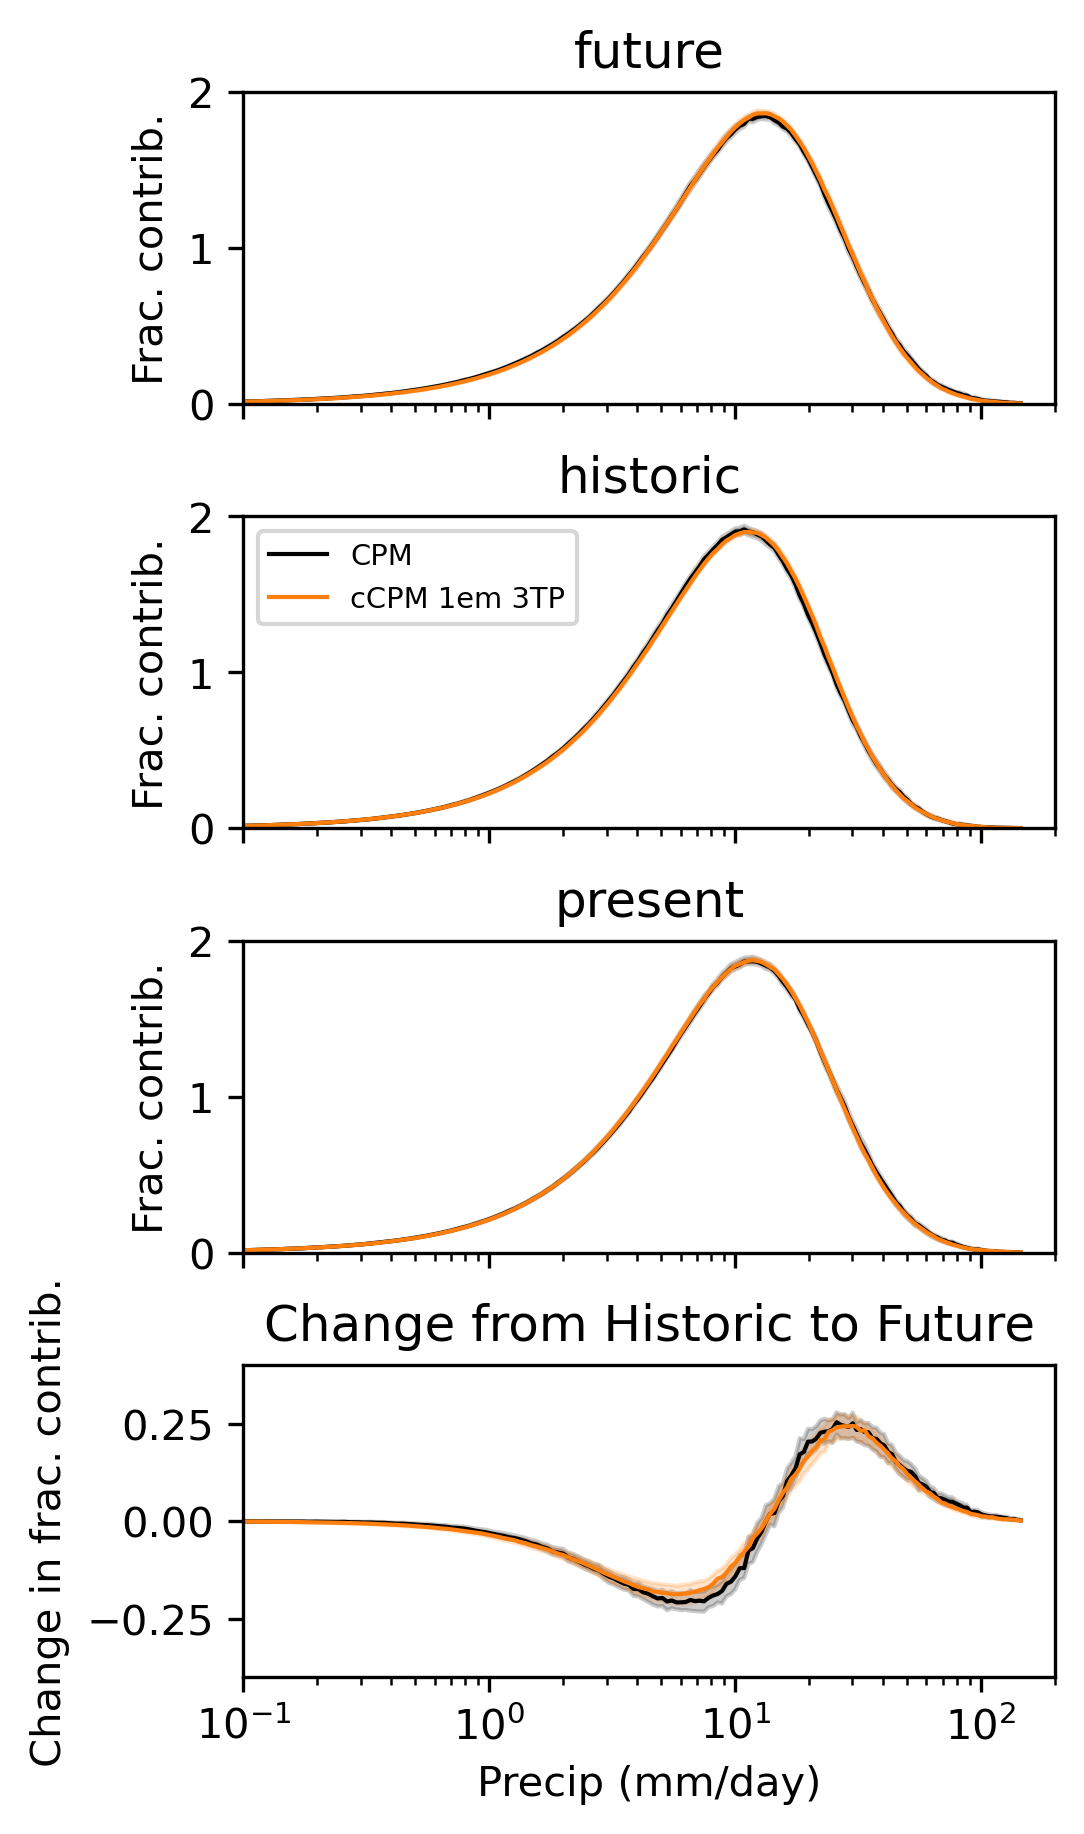

#### cCPM 12em 3TP

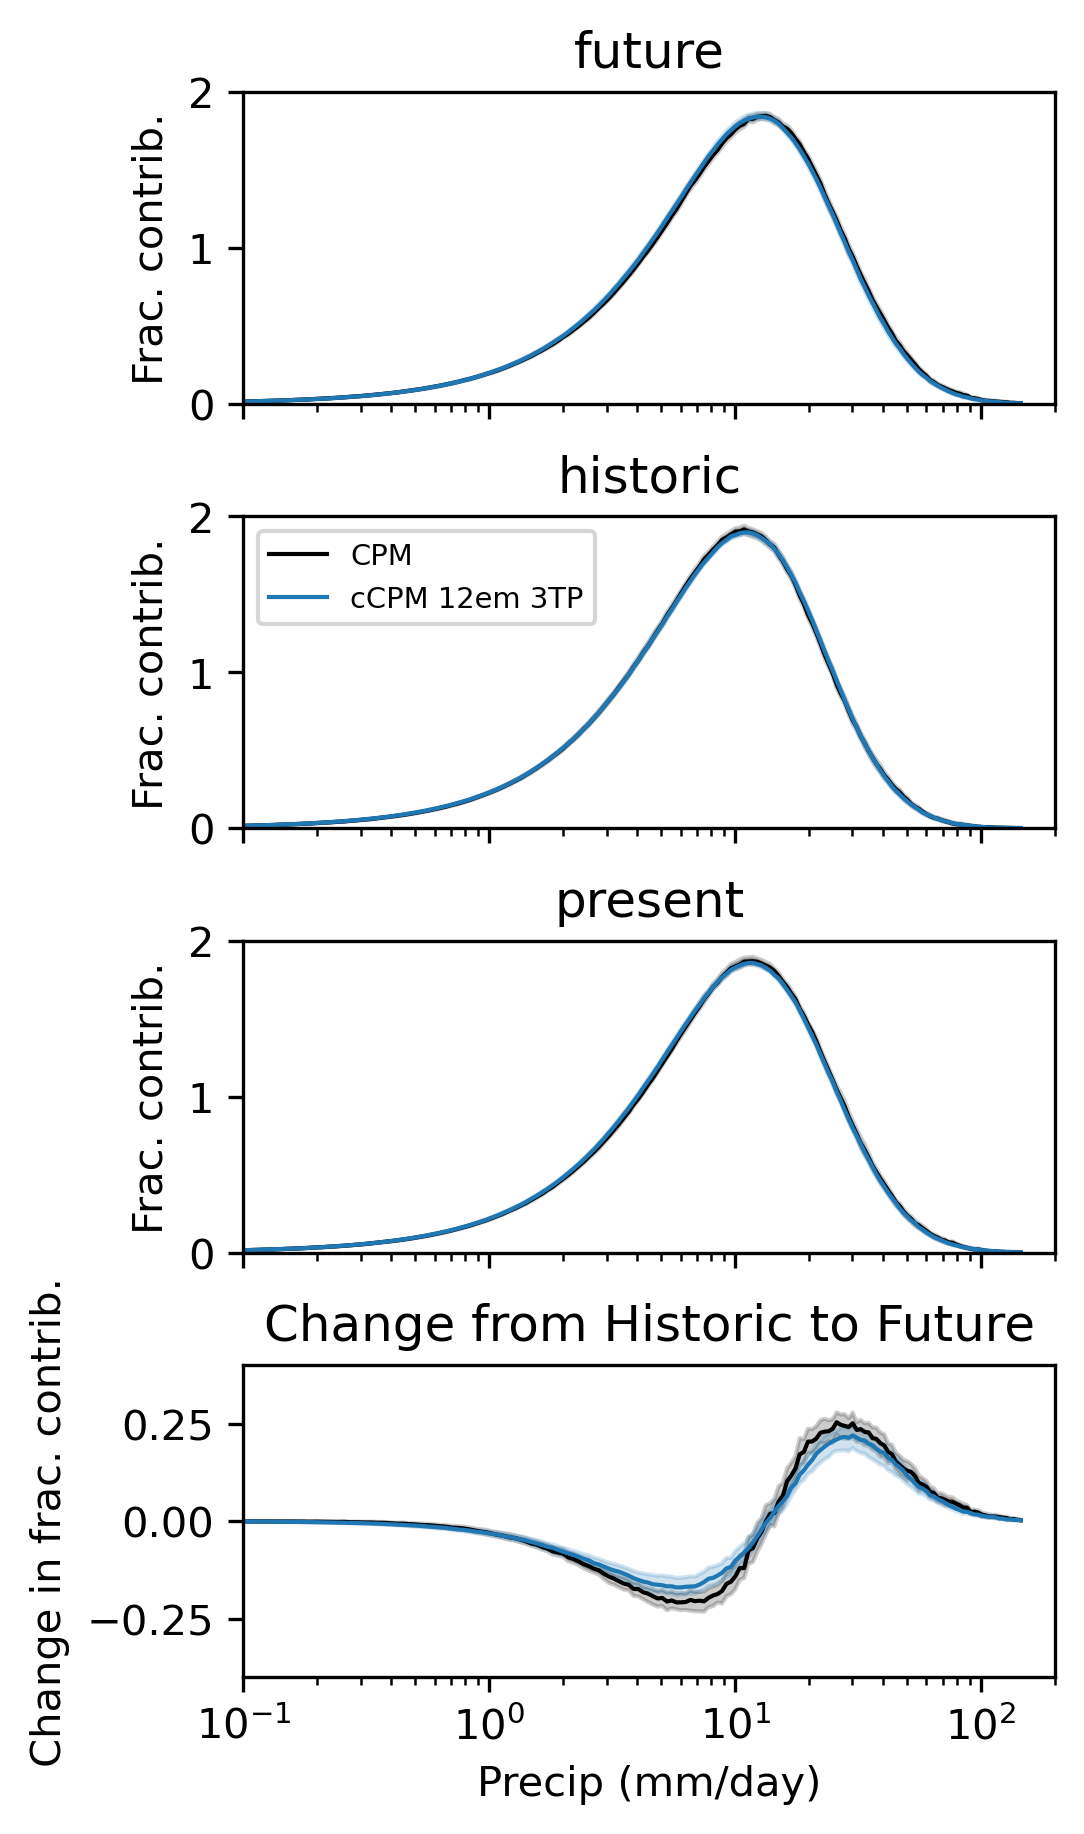

In [ ]:
for var, bs_cpm_da in bs_cpm_das.items():

    for model, model_pred_da in CCS_VAR_DAS[var][f"pred_{var}"].groupby("model", squeeze=False):

        IPython.display.display_markdown(f"#### {model}", raw=True)    

        bs_pred_da = chained_groupby_map(model_pred_da.squeeze("model"), ["time_period", "time.season"], resample_examples, niterations=niterations)

        fcdata = ccs_fc_da(bs_pred_da.expand_dims(model=[model]), bs_cpm_da, extra_pred_dims=["iteration"], extra_cpm_dims=["iteration"])
        
        fig = plt.figure(layout='constrained', figsize=(3.5, 6))
        plot_ccs_fc_figure(fig, fcdata, palette={label: spec["color"] for label, spec in MODELLABEL2SPEC.items()}, errorbar=("pi", 90))
        plt.show()
    
        del bs_pred_da

In [ ]:
del bs_cpm_das

#### cCPM 1em 3TP

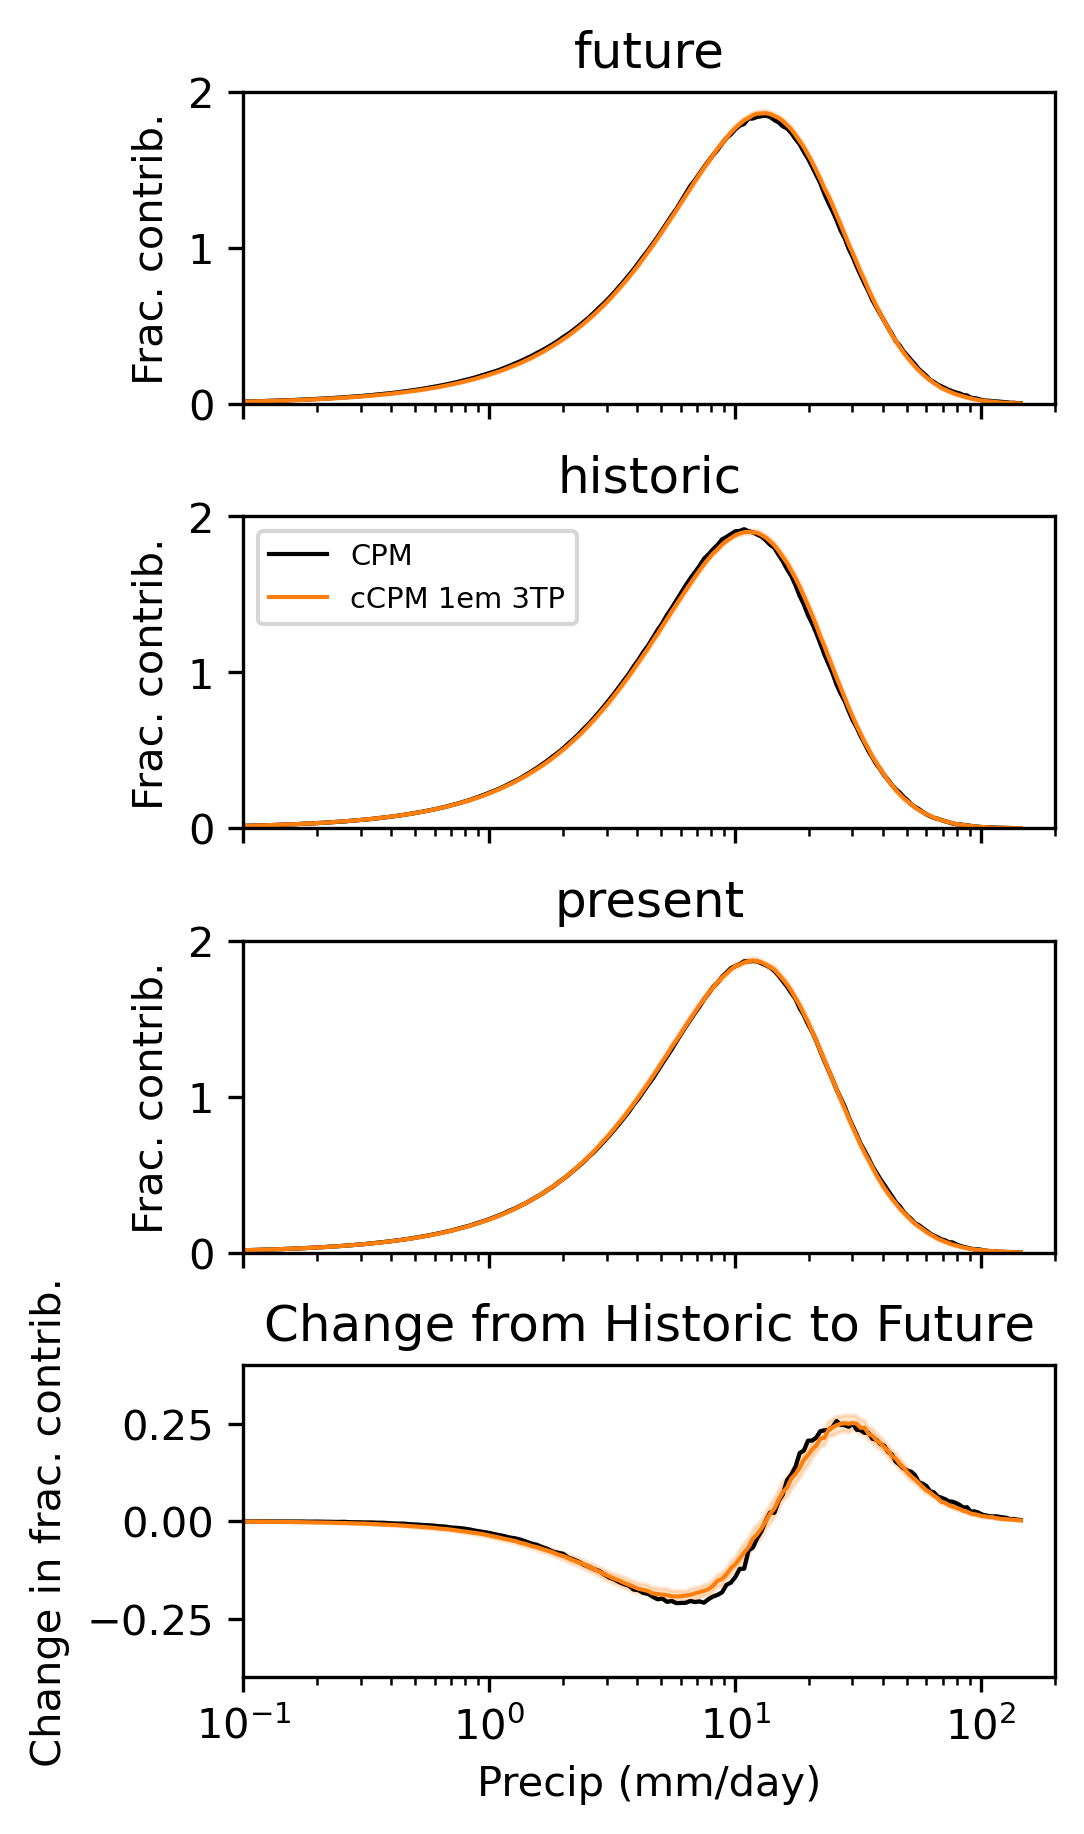

#### cCPM 12em 3TP

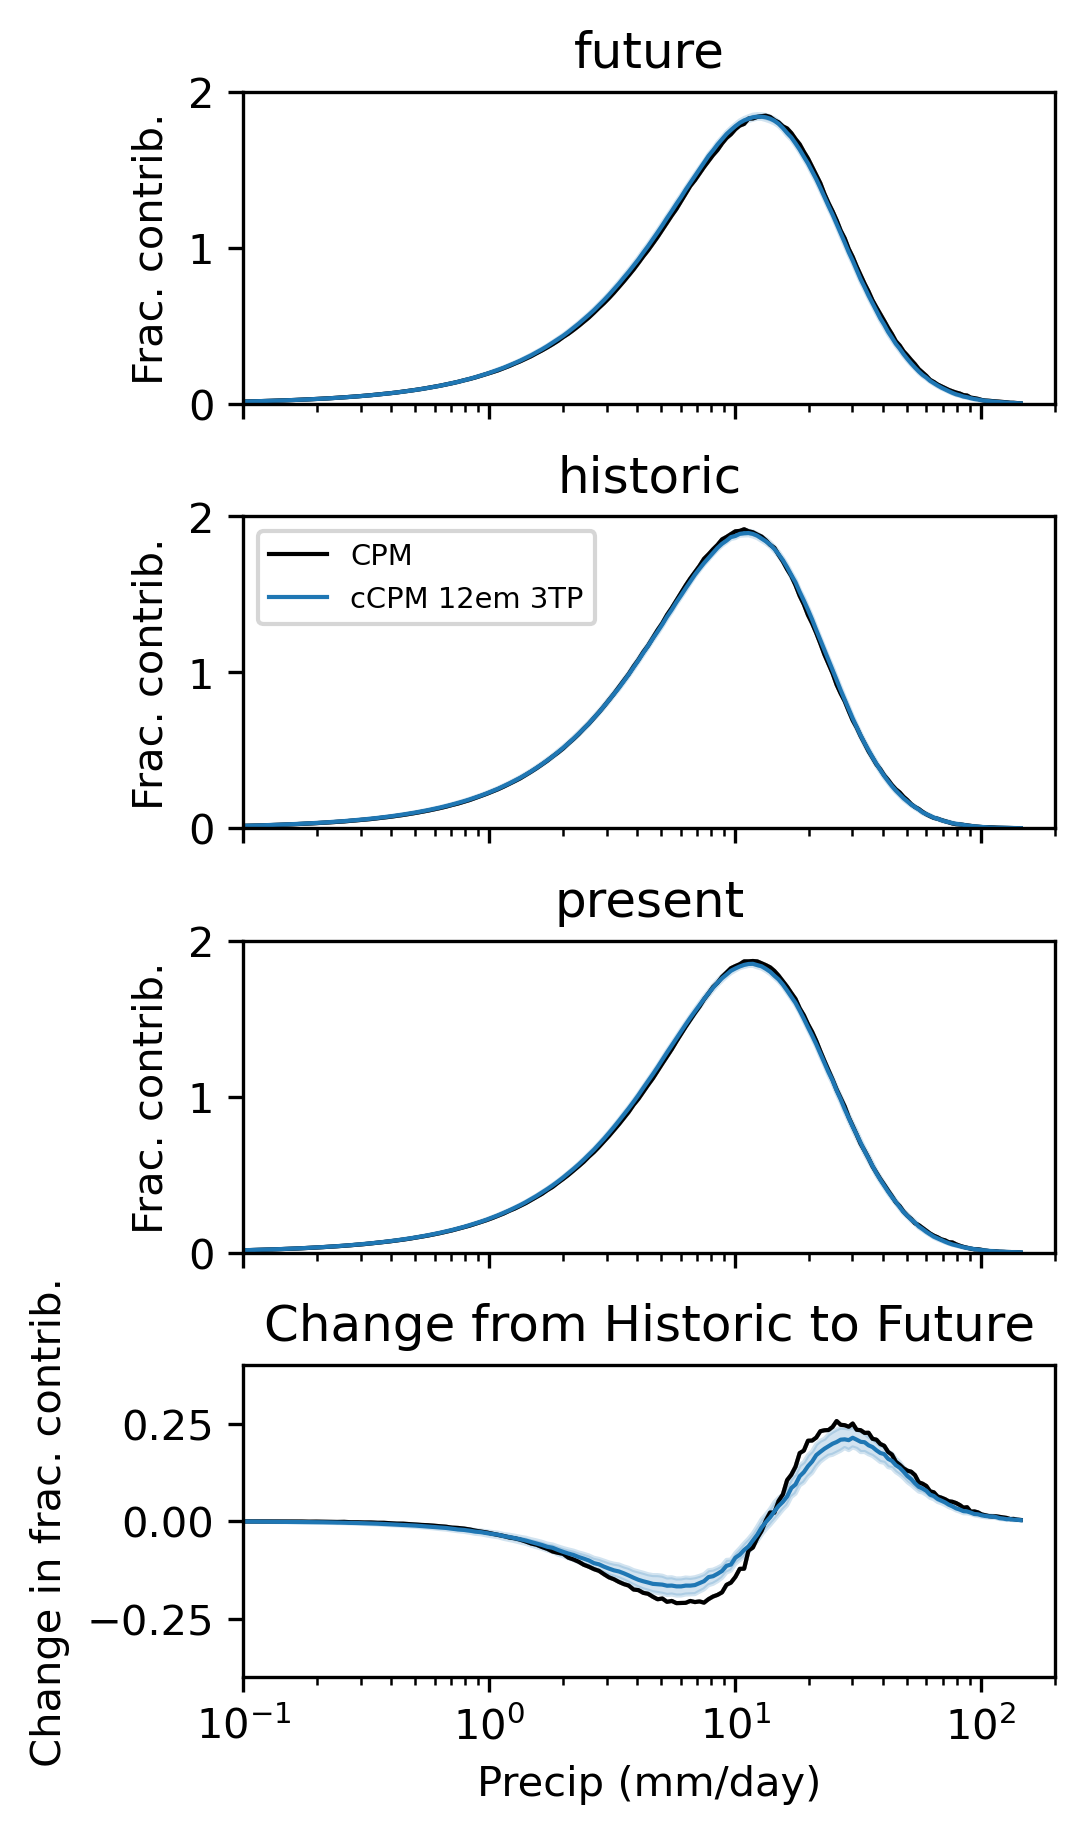

In [ ]:
for var in eval_vars:
    if var not in ["pr"]:
        continue

    for model, model_pred_da in CCS_VAR_DAS[var][f"pred_{var}"].groupby("model", squeeze=False):

        IPython.display.display_markdown(f"#### {model}", raw=True)    

        bs_pred_da = chained_groupby_map(model_pred_da.squeeze("model"), ["time_period", "time.season"], resample_examples, niterations=niterations)

        fcdata = ccs_fc_da(bs_pred_da.expand_dims(model=[model]), CCS_VAR_DAS[var][f"target_{var}"], extra_pred_dims=["iteration"])
        
        fig = plt.figure(layout='constrained', figsize=(3.5, 6))
        plot_ccs_fc_figure(fig, fcdata, palette={label: spec["color"] for label, spec in MODELLABEL2SPEC.items()}, errorbar=("pi", 90))
        plt.show()
    
        del bs_pred_da